**<h1 align="center">Universidad Internacional del Ecuador</h1>**

**<h2 align="center">Visión por Computador</h2>**

***<h3 align="left">Grupo 8</h3>***
- ***<h3 align="left">DARIO WLADIMIR HERRERA CHÁVEZ</h3>***
- ***<h3 align="left">FABIAN PATRICIO AGUIRRE PAREJA</h3>***
- ***<h3 align="left">JORGE ARMANDO QUIZAMANCHURO FUEL</h3>***
- ***<h3 align="left">JONATHAN ANDRES VASCO CALVACHE</h3>***

> *Repositorio*
>
> https://github.com/daros10/UIDE-Vision-Por-Computador-Homework-1

## - Extracción de características | Parte I

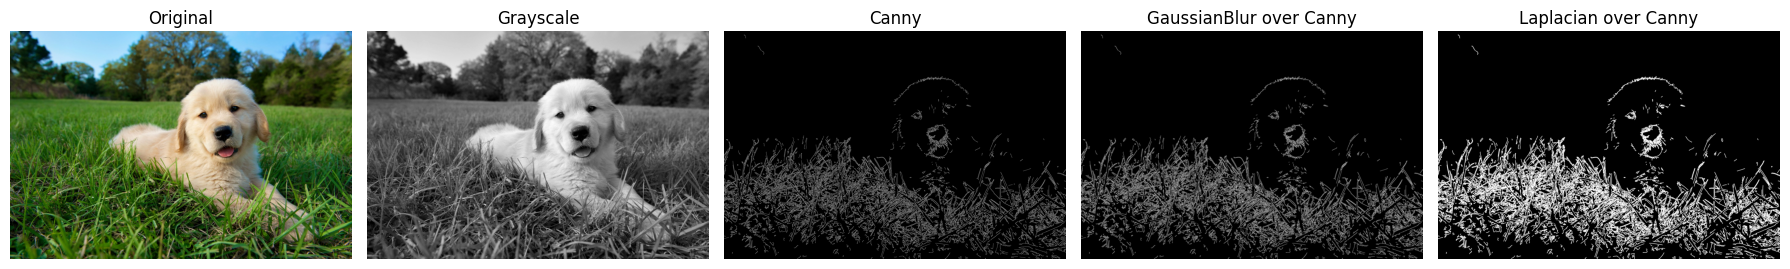

In [1]:
import cv2
import matplotlib.pyplot as plt

ruta_archivo = "resources/imgs/dog.jpg"
img_bgr = cv2.imread(ruta_archivo)

if img_bgr is None:
    print(f"Error: No se encontró la imagen en {ruta_archivo}")
else:
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

    image_gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)

    edges = cv2.Canny(image_gray, 100, 200)

    blur = cv2.GaussianBlur(edges, (5, 5), 0)

    lap = cv2.Laplacian(edges, cv2.CV_64F)
    lap = cv2.convertScaleAbs(lap)

    plt.style.use("default")
    fig, axs = plt.subplots(1, 5, figsize=(18, 5))

    axs[0].imshow(img_rgb)
    axs[0].set_title("Original")

    axs[1].imshow(image_gray, cmap="gray")
    axs[1].set_title("Grayscale")

    axs[2].imshow(edges, cmap="gray")
    axs[2].set_title("Canny")

    axs[3].imshow(blur, cmap="gray")
    axs[3].set_title("GaussianBlur over Canny")

    axs[4].imshow(lap, cmap="gray")
    axs[4].set_title("Laplacian over Canny")

    for ax in axs:
        ax.axis("off")

    plt.tight_layout()
    plt.show()

-Al aplicar el filtro Canny, se pueden apreciar con claridad los bordes de la imagen, destacando los contornos principales del perro y el pasto.

-Cuando se aplica un filtro Gaussiano sobre la salida de Canny, los bordes detectados se suavizan, mostrando un efecto más uniforme. Esto es útil para pruebas, aunque en un flujo típico de procesamiento de imágenes, el suavizado se aplicaría antes de ejecutar Canny para reducir el ruido y mejorar la detección de bordes.

-Por último, al usar el filtro Laplaciano sobre la imagen procesada con Canny, se intensifican aún más los detalles de los bordes, haciendo que los contornos sean más marcados y visibles.

## - Clasificación de imágenes | Parte II

Procedemos a cargar la fuente de imágenes, en este caso se seleccióno el dataset del repositorio de CIFAR-10

In [2]:
import pickle
import numpy as np
import matplotlib.pyplot as plt

with open('resources/cifar/data_batch_1', 'rb') as f:
    batch = pickle.load(f, encoding='bytes')

plt.style.use("default")

La clasificación que se realizara será entre 2 clases, la primera tipo *airplane (avión)* y la segunda de tipo *ship (barco)*

- CIFAR-10 ofrece su dataset de imágenes como vectores y etiquetas dentro de sus archivos *data_batch_[x].bin* en tamaños de 32x32 px.
- CIFAR-10 cuenta con un catálogo de labels de las fotografías basado en un orden predeterminado, el mismo se encuentra en la variable *cifar_10_predeterminate_labels*

In [3]:
images_data = batch[b'data']
labels_data = batch[b'labels']

cifar_10_predeterminate_labels = ["airplane","automobile","bird","cat","deer","dog","frog","horse","ship","truck"]

Generamos una función que nos permite crear nuestro dataset de pruebas y a la vez nos permite visualizar *n* números de imágenes de dicho dataset

In [4]:
def get_imgs_by_class(img_data, label_data, cifar_label_id, cifar_predeterminate_labels, cifar_number_imgs= 100, number_img_show=20):
    class_index = np.where(np.array(label_data) == cifar_label_id)[0]

    if cifar_number_imgs is None:
        cifar_number_imgs = len(class_index)

    cifar_number_imgs = min(cifar_number_imgs, len(class_index))

    selected_images = []

    for idx in class_index[:cifar_number_imgs]:
        img = img_data[idx].reshape(3, 32, 32).transpose(1, 2, 0)
        selected_images.append(img)

    selected_images = np.array(selected_images)

    print(f"{cifar_predeterminate_labels[cifar_label_id].upper()} | Size: {len(selected_images)} imgs")

    number_img_show = min(number_img_show, len(selected_images))

    cols = 5
    rows = int(np.ceil(number_img_show / cols))

    plt.figure(figsize=(cols*2, rows*2))

    for i in range(number_img_show):
        plt.subplot(rows, cols, i+1)
        plt.imshow(selected_images[i].astype("uint8"))
        plt.axis("off")

    plt.suptitle(cifar_predeterminate_labels[cifar_label_id].upper())
    plt.tight_layout()
    plt.show()

    return selected_images

### Airplane (Avión)

Procedemos a guardar 1000 imágenes de la primera clase tipo *Airplane* en nuestro *array airplane_images*.

Mostramos 5 imágenes de ejemplo del dataset.

El mismo posteriormente será usado para realizar operaciones de test y train.

AIRPLANE | Size: 1000 imgs


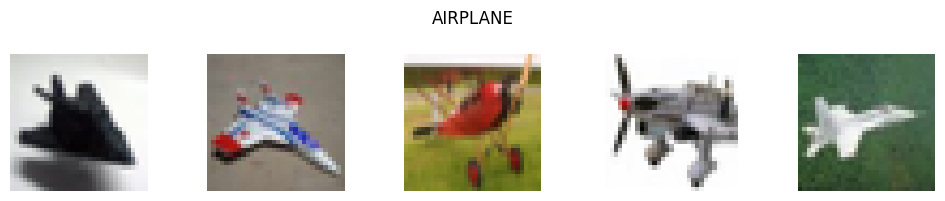

In [5]:
airplane_index = 0

airplane_images = get_imgs_by_class(
    images_data,
    labels_data,
    cifar_label_id = airplane_index,
    cifar_predeterminate_labels = cifar_10_predeterminate_labels,
    cifar_number_imgs = 1000,
    number_img_show = 5
)

### Ship (Barco)

Ahora, procedemos a guardar 1000 imágenes de la segunda clase tipo *Ship* en nuestro *array ship_images*.

Mostramos 5 imágenes de ejemplo del dataset.

El mismo posteriormente será usado para realizar operaciones de test y train.

SHIP | Size: 1000 imgs


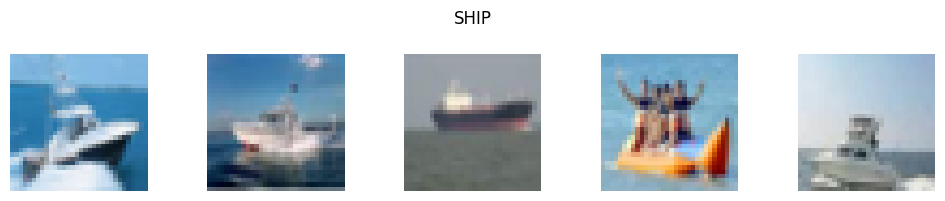

In [6]:
ship_index = 8

ship_images = get_imgs_by_class(
    images_data,
    labels_data,
    cifar_label_id = ship_index,
    cifar_predeterminate_labels = cifar_10_predeterminate_labels,
    cifar_number_imgs = 1000,
    number_img_show = 5
)

### Dataset a operar

Contamos con 2 clases de tipo *Airplane* y *Ship*.

Existen 1000 Airplanes y 1000 Ship, en total 2000 imágenes para el proceso de clasificación de imágenes.

Se estableció ese número para operar sobre un entorno más real, ya que 20 imágenes por clase es muy poco para el proceso de train y test.

In [7]:
all_dataset_size = len(airplane_images) + len(ship_images)
print(f"Size of all dataset (Airplane and Ship): {all_dataset_size}")

Size of all dataset (Airplane and Ship): 2000


- Generamos un único dataset con todas las imágenes de aviónes y barcos.
- Creamos un vector de 0 y 1 para aviónes y barcos respectivamente.
- El etiquetado permite diferenciar el target.
- Finalmente, combinamos los vectores de etiquetas de los aviónes y barcos.

In [8]:
X_imgs = np.concatenate((airplane_images, ship_images))

airplane_label_vector = [0]*len(airplane_images)
ship_label_vector = [1]*len(ship_images)

y_labels = np.array(airplane_label_vector + ship_label_vector)

print(X_imgs.shape)
print(y_labels.shape)

(2000, 32, 32, 3)
(2000,)


## SVM con Método HOG

Para la clasificación y extracción de características de nuestro dataset, usaremos *SVM (Support Vector Machine)* y *HOG (Histogram of Orientated Gradient)*.

El modelo SVM nos va a permitir realizar la clasificación de nuestras imágenes de manera supervisada, el modo en que funciona básicamente se reduce a "aprender" a separar clases.

Por otra parte, HOG permite la extracción de características mediante el uso de detección de bordes, intensidad del gradiente y formas de la imagen, en forma de vector.

Con las definiciones previas procedemos a trasformar a grises todo nuestro set de imágenes para proceder a realizar los procesos a continuación descritos.

In [9]:
from skimage.color import rgb2gray

X_gray = np.array([rgb2gray(img) for img in X_imgs])

print(X_gray.shape)

(2000, 32, 32)


### Extracción de características

Usando la función HOG procedemos a realizar la extracción de caracterísitcas de nuestro dataset en escala de grises.

Los parámetros de la función HOG se describen a continuación:

- orientations = Permite dividir la dirección de los bordes en N ángulos posibles
- pixels_per_cell = Permite dividir celdas para pixeles en NxN
- cells_per_block = Permite agrupar celdas en NxN para normalizar la iluminación
- visualize = Bandera que permite controla la visualización de la imágen


In [10]:
from skimage.feature import hog

hog_features = []

for img in X_gray:
    features = hog(
        img,
        orientations = 9,
        pixels_per_cell = (8,8),
        cells_per_block = (2,2),
        visualize = False
    )
    hog_features.append(features)

X_features = np.array(hog_features)
print(X_features.shape)

(2000, 324)


### División Dataset

Con la respectiva obtención de características con el método HOG, procedemos a separar nuestro dataset en elementos de train y test.

En este caso seleccionamos el 30% del total de nuestro dataset para el proceso de testeo.

El conjunto de 2000 imágenes se distribuyen de la siguiente manera:

- 1400 imágenes para entrenamiento
- 600 imágenes para pruebas

In [11]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test, img_train, img_test = train_test_split(
    X_features,
    y_labels,
    X_imgs,
    test_size = 0.3,
    random_state = 42,
    stratify = y_labels
)

print(f"Size of training set: {len(X_train)}")
print(f"Size of test set: {len(X_test)}")

Size of training set: 1400
Size of test set: 600


### Entrenamiento del Clasificador

Como ya se mencionó, usaremos el modelo SVM (Support Vector Machine) para realizar nuestro entrenamiento.

En este caso el Kernel que usaremos en el método SVC que contiene la implementación del algoritmo SVM es "linear".

Se usa el kernel "linear", ya que el método HOG prácticamente permite generar clases separables linealmente, además que permite un entrenamiento rápido y un uso menor de memoria.

In [12]:
from sklearn.svm import SVC

model = SVC(kernel="linear")

model.fit(X_train, y_train)

SVC(kernel='linear')

### Predicción sobre el Dataset de Test

In [13]:
y_pred = model.predict(X_test)

print(y_pred)

[0 0 0 1 0 1 0 1 1 1 1 1 1 1 0 0 1 0 1 1 1 1 0 1 1 0 0 1 1 0 1 1 1 0 0 0 1
 0 1 0 1 0 1 1 0 1 0 1 1 0 1 0 1 1 1 1 1 0 0 1 1 0 1 1 1 1 0 1 1 0 1 1 1 0
 0 1 1 1 1 0 1 1 1 1 0 0 1 0 1 1 0 0 0 1 1 1 0 0 1 0 1 1 1 0 0 1 1 0 0 0 1
 1 0 1 1 0 0 1 0 1 0 1 0 0 1 0 0 1 1 1 0 1 0 0 0 1 1 0 1 1 1 0 1 0 1 1 0 0
 1 0 1 0 1 1 1 0 0 0 0 0 1 1 0 0 1 0 0 1 0 1 0 1 0 0 1 1 0 0 1 0 0 1 0 1 1
 1 0 1 1 0 1 1 1 0 0 0 0 1 1 1 1 0 0 1 1 0 1 1 1 1 0 1 1 1 0 0 1 1 0 1 0 1
 0 1 1 0 0 0 1 0 1 0 1 1 0 0 1 0 0 0 0 1 0 1 1 1 0 1 1 1 1 1 0 0 1 1 0 1 0
 0 0 1 1 1 0 0 1 1 0 1 1 0 1 1 0 1 1 0 0 1 0 1 1 1 1 1 1 0 0 1 1 0 1 1 1 0
 1 0 1 0 1 1 1 1 0 0 1 1 0 1 1 1 1 1 1 1 0 0 1 0 1 1 1 1 1 1 1 1 0 1 0 0 0
 1 1 0 0 1 0 0 0 1 1 1 1 1 0 1 1 0 0 0 1 0 0 0 0 1 0 1 1 0 0 0 0 0 0 0 1 1
 0 1 1 0 0 1 0 1 1 0 0 1 0 1 1 1 0 1 1 0 0 0 0 0 1 1 0 0 1 1 1 1 1 0 1 0 1
 0 1 0 0 1 1 0 1 1 1 0 1 0 0 0 1 0 0 0 0 0 0 0 1 0 1 0 1 0 1 1 1 1 0 1 1 0
 0 1 0 1 0 1 1 1 0 0 1 1 1 0 1 0 1 0 0 0 0 1 1 1 1 0 1 1 1 1 0 0 0 0 1 0 0
 0 1 1 1 0 0 0 1 0 0 1 0 

### Predicción Visual sobre el Dataset de Test

Creamos una función que nos permite iterar sobre nuestro dataset de pruebas, el mismo que de manera gráfica nos indica si el modelo acertó o no.

Como se puede observar con un set de 30 imágenes de prueba, los resultados del modelo son buenos, "casi" no se equivoca.

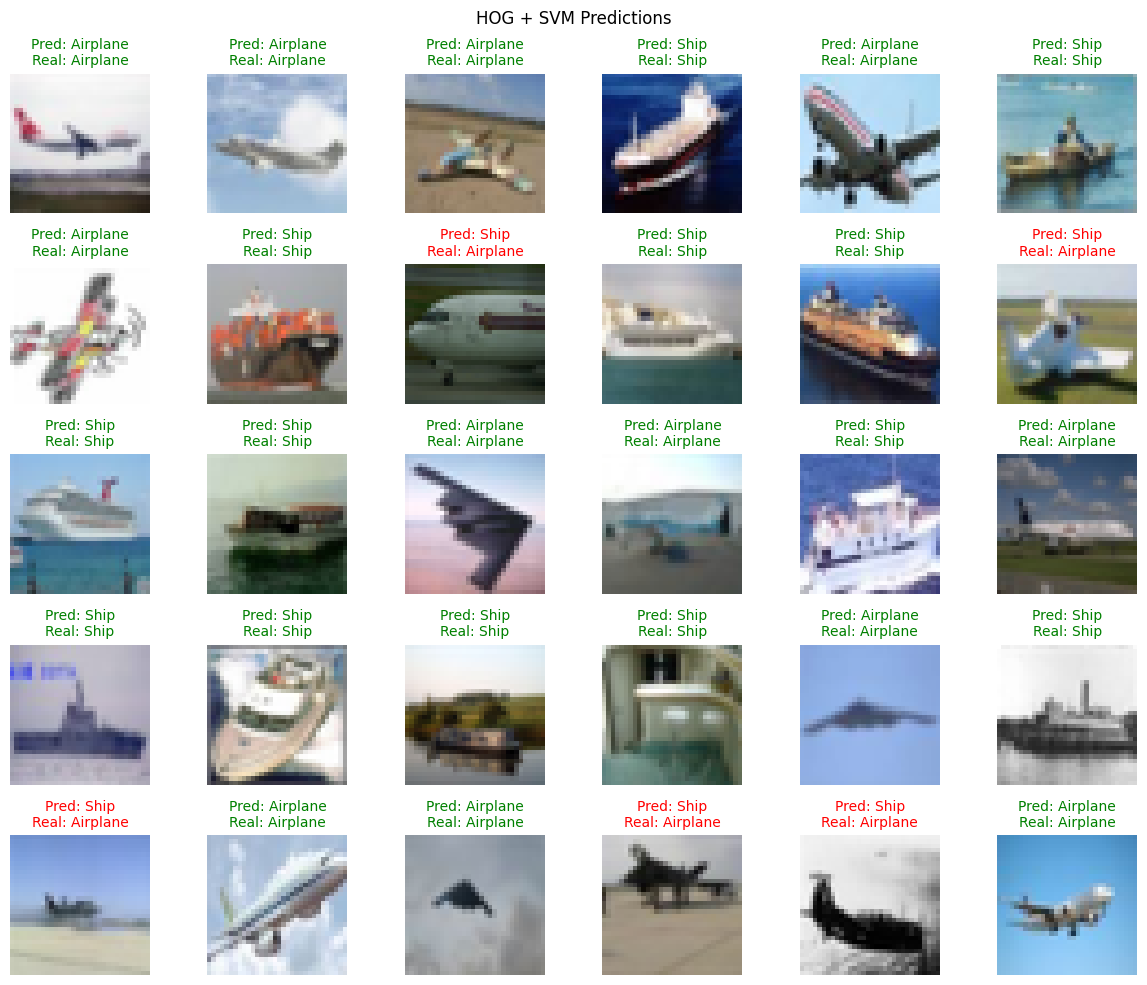

In [15]:
class_names = ["Airplane", "Ship"]

def show_predictions(img_test, y_test, y_pred, class_names, n_images=5):
    n_images = min(n_images, len(img_test))

    cols = int(np.ceil(np.sqrt(n_images)))
    rows = int(np.ceil(n_images / cols))

    plt.figure(figsize=(cols*2, rows*2))

    for i in range(n_images):
        plt.subplot(rows, cols, i+1)

        img = img_test[i]

        pred = y_pred[i]
        true = y_test[i]

        color = "green" if pred == true else "red"

        plt.imshow(img.astype("uint8"))

        plt.title(
            f"Pred: {class_names[pred]}\nReal: {class_names[true]}",
            color=color,
            fontsize=10
        )

        plt.axis("off")

    plt.suptitle("HOG + SVM Predictions")
    plt.tight_layout()
    plt.show()

show_predictions(img_test, y_test, y_pred, class_names, n_images=30)

### Evaluación del modelo

Una vez revisada de manera gráfica el modelo, procedemos a realizar una evaluación cuantitativa de la precisión.

Se obtuvo un score del *77.33%* de precisión.

El accuracy es bueno, eso se debe a que HOG permite distinguir siluetas, mediante la captura de bordes, forma y orientación, las mismas que en nuestro caso son muy diferentes.

In [16]:
from sklearn.metrics import accuracy_score

y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred) * 100

print(f"Accuracy: {accuracy:.2f}%")

Accuracy: 77.33%


### Matriz de confusión

Mediante la matriz de confusión podemos inferir los siguientes resultados:

- 219 aviones clasificados correctamente como avión
- 81 aviones que el modelo confundió con barco
- 55 barcos que el modelo confundió con avión
- 245 barcos clasificados correctamente como barcos

[[219  81]
 [ 55 245]]


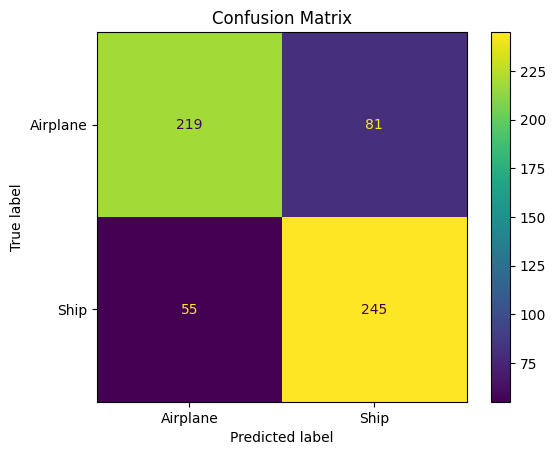

In [17]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot()

plt.title("Confusion Matrix")
plt.show()

Normalizando la information obtenida en la matriz de confusión podemos observar los resultados en términos de porcentaje.

- Aviones = 73% correctos
- Barcos = 82% correctos

*En este sentido podemos concluir que nuestro modelo es mucho mejor clasificando barcos que aviones.*

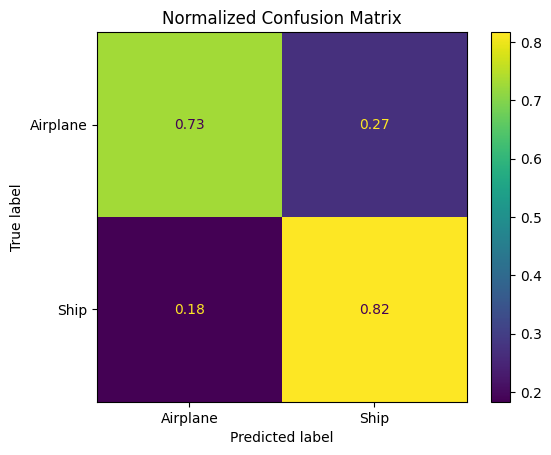

In [18]:
disp = ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=class_names,
    normalize="true"
)

plt.title("Normalized Confusion Matrix")
plt.show()